# 02 — RFM Segmentation

**Goal:** Score every customer on Recency, Frequency, and Monetary value, then assign them to CRM segments that can drive targeted marketing actions.

**Inputs:** `../data/cleaned/customer_summary.csv`  
**Output:** `../data/cleaned/rfm_segments.csv`

## 1. Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

CLEAN_PATH = '../data/cleaned/'
COLORS = ['#1F4E79', '#2E75B6', '#4BACC6', '#9DC3E6', '#D6E4F0']

customer_summary = pd.read_csv(CLEAN_PATH + 'customer_summary.csv', parse_dates=['first_order', 'last_order'])
print(f'Loaded {len(customer_summary):,} customers')
customer_summary.head()

Loaded 93,349 customers


,customer_id_unique,first_order,last_order,order_count,total_spend,avg_order_value,avg_review_score,top_category,state,recency_days,tenure_days
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,2018-05-10 10:56:27,1,141.90,141.90,5.0,bed_bath_table,SP,112,112
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,2018-05-07 11:11:27,1,27.19,27.19,4.0,health_beauty,SP,115,115
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,2017-03-10 21:05:03,1,86.22,86.22,3.0,stationery,SC,537,537
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,2017-10-12 20:29:41,1,43.62,43.62,4.0,telephony,PA,321,321
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,2017-11-14 19:45:42,1,196.89,196.89,5.0,telephony,SP,288,288


## 2. Calculate RFM Scores

In [3]:
rfm = customer_summary[['customer_id_unique', 'recency_days', 'order_count', 'total_spend']].copy()
rfm.columns = ['customer_id', 'recency', 'frequency', 'monetary']

# Score 1-5 using quintiles
# Recency: lower is better (more recent), so we reverse the scoring
rfm['R'] = pd.qcut(rfm['recency'], q=5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm['F'] = pd.qcut(rfm['frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm['M'] = pd.qcut(rfm['monetary'], q=5, labels=[1, 2, 3, 4, 5]).astype(int)

rfm['RFM_Score'] = rfm['R'].astype(str) + rfm['F'].astype(str) + rfm['M'].astype(str)
rfm['RFM_Total'] = rfm['R'] + rfm['F'] + rfm['M']

print('RFM scores calculated')
rfm[['R', 'F', 'M', 'RFM_Total']].describe()

RFM scores calculated


,R,F,M,RFM_Total
count,93349.000000,93349.000000,93349.000000,93349.000000
mean,3.003203,3.000000,2.999754,9.002957
std,1.414289,1.414229,1.414263,2.499088
min,1.000000,1.000000,1.000000,3.000000
25%,2.000000,2.000000,2.000000,7.000000
50%,3.000000,3.000000,3.000000,9.000000
75%,4.000000,4.000000,4.000000,11.000000
max,5.000000,5.000000,5.000000,15.000000


## 3. Assign CRM Segments

In [4]:
def assign_segment(row):
    r, f, m = row['R'], row['F'], row['M']
    score = row['RFM_Total']

    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'Recent Customers'
    elif r >= 3 and f >= 2 and m >= 3:
        return 'Potential Loyalists'
    elif r == 3 and f <= 2:
        return 'Promising'
    elif r <= 2 and f >= 3 and m >= 3:
        return 'At Risk'
    elif r <= 2 and f >= 2:
        return 'Cannot Lose Them'
    elif r <= 2 and f <= 2 and m >= 3:
        return 'Hibernating'
    else:
        return 'Lost'

rfm['Segment'] = rfm.apply(assign_segment, axis=1)

segment_summary = rfm.groupby('Segment').agg(
    customer_count=('customer_id', 'count'),
    avg_recency=('recency', 'mean'),
    avg_frequency=('frequency', 'mean'),
    avg_monetary=('monetary', 'mean'),
    total_revenue=('monetary', 'sum')
).round(2)

segment_summary['pct_customers'] = (segment_summary['customer_count'] / len(rfm) * 100).round(1)
segment_summary['pct_revenue'] = (segment_summary['total_revenue'] / rfm['monetary'].sum() * 100).round(1)
segment_summary = segment_summary.sort_values('total_revenue', ascending=False)

print('Segment Summary:')
segment_summary

Segment Summary:


,customer_count,avg_recency,avg_frequency,avg_monetary,total_revenue,pct_customers,pct_revenue
Segment,,,,,,,
Loyal Customers,27290,144.22,1.03,133.99,3656604.33,29.2,23.7
At Risk,13164,393.50,1.07,243.53,3205790.21,14.1,20.8
Recent Customers,14980,90.89,1.00,163.42,2448079.38,16.0,15.9
Champions,6492,91.12,1.18,312.15,2026452.22,7.0,13.1
Cannot Lose Them,16567,395.40,1.01,104.39,1729387.59,17.7,11.2
Hibernating,4330,397.07,1.00,240.85,1042882.13,4.6,6.8
Promising,5222,219.82,1.00,125.06,653065.97,5.6,4.2
Potential Loyalists,2152,221.29,1.00,224.58,483293.59,2.3,3.1
Lost,3152,396.28,1.00,55.69,175527.43,3.4,1.1


## 4. Visualise Segments

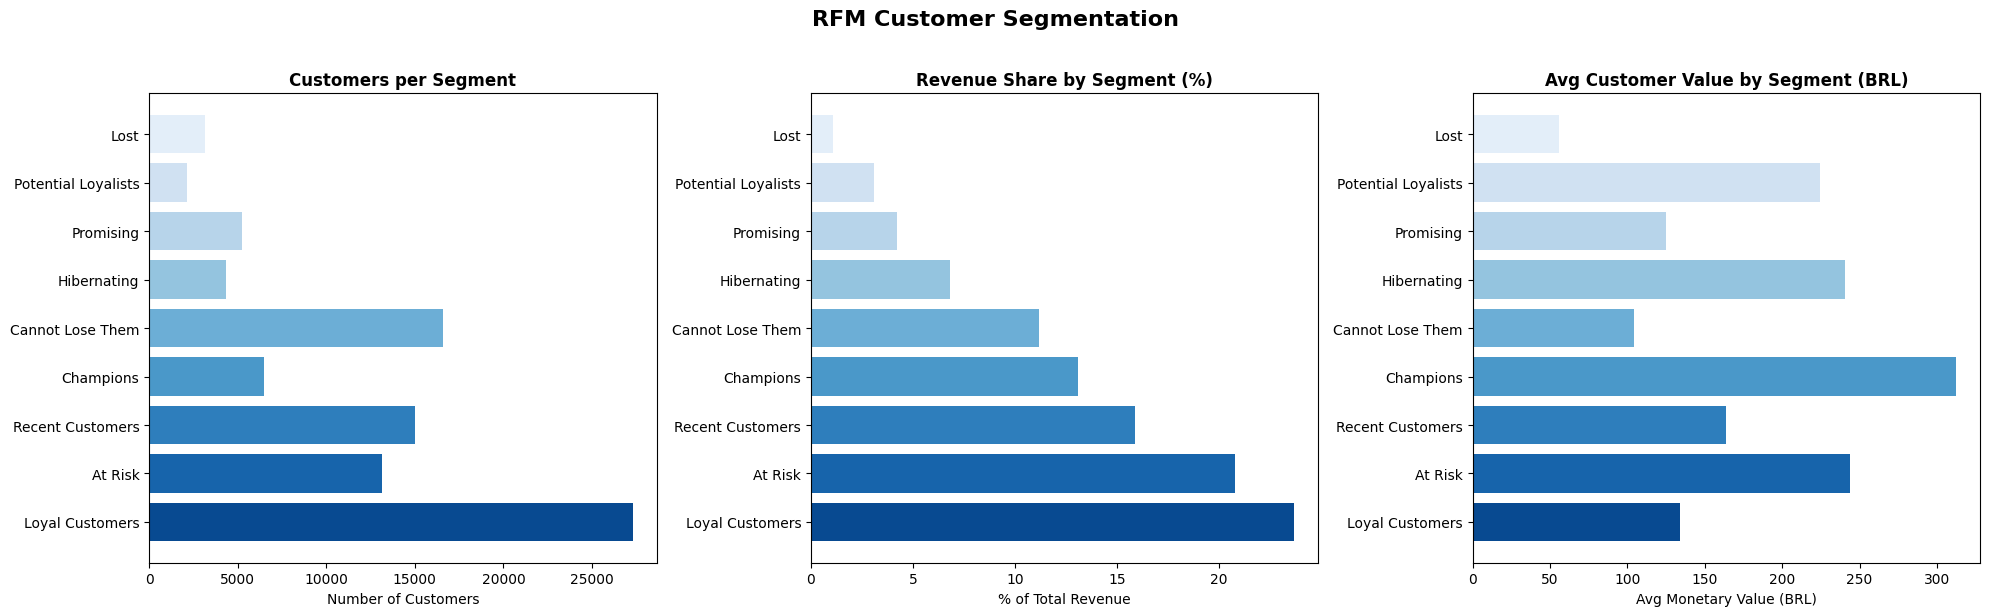

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('RFM Customer Segmentation', fontsize=16, fontweight='bold', y=1.02)

segment_order = segment_summary.index.tolist()
palette = sns.color_palette('Blues_r', len(segment_order))

# Customer count by segment
counts = segment_summary['customer_count'].reindex(segment_order)
axes[0].barh(segment_order, counts.values, color=palette)
axes[0].set_title('Customers per Segment', fontweight='bold')
axes[0].set_xlabel('Number of Customers')

# Revenue share by segment
revenue = segment_summary['pct_revenue'].reindex(segment_order)
axes[1].barh(segment_order, revenue.values, color=palette)
axes[1].set_title('Revenue Share by Segment (%)', fontweight='bold')
axes[1].set_xlabel('% of Total Revenue')

# Avg monetary by segment
avg_m = segment_summary['avg_monetary'].reindex(segment_order)
axes[2].barh(segment_order, avg_m.values, color=palette)
axes[2].set_title('Avg Customer Value by Segment (BRL)', fontweight='bold')
axes[2].set_xlabel('Avg Monetary Value (BRL)')

plt.tight_layout()
plt.savefig('../reports/02_rfm_segments.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# RFM scatter — Recency vs Frequency, coloured by segment
plt.figure(figsize=(12, 7))
segments_unique = rfm['Segment'].unique()
colors = sns.color_palette('tab10', len(segments_unique))

for i, seg in enumerate(segments_unique):
    subset = rfm[rfm['Segment'] == seg]
    plt.scatter(subset['recency'], subset['frequency'],
                label=seg, alpha=0.5, s=20, color=colors[i])

plt.xlabel('Recency (days since last order)', fontsize=12)
plt.ylabel('Frequency (number of orders)', fontsize=12)
plt.title('Customer Segments: Recency vs Frequency', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../reports/02_rfm_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. CRM Action Recommendations per Segment

In [6]:
crm_actions = {
    'Champions':          'Reward and upsell. Ask for reviews. Enrol in loyalty programme.',
    'Loyal Customers':    'Upsell higher value products. Offer early access to new products.',
    'Potential Loyalists':'Offer membership or loyalty programme. Recommend related products.',
    'Recent Customers':   'Onboarding campaign. Provide helpful content. Encourage second purchase.',
    'Promising':          'Create brand awareness. Offer limited-time promotions.',
    'At Risk':            'Send personalised win-back emails. Offer discount on next order.',
    'Cannot Lose Them':   'Aggressive win-back campaign. Survey to understand drop-off.',
    'Hibernating':        'Reactivation campaign with strong incentive.',
    'Lost':               'Low priority. Generic reactivation or suppress from campaigns.'
}

rfm['CRM_Action'] = rfm['Segment'].map(crm_actions)

action_df = pd.DataFrame(list(crm_actions.items()), columns=['Segment', 'Recommended CRM Action'])
print(action_df.to_string(index=False))

            Segment                                                   Recommended CRM Action
          Champions          Reward and upsell. Ask for reviews. Enrol in loyalty programme.
    Loyal Customers        Upsell higher value products. Offer early access to new products.
Potential Loyalists       Offer membership or loyalty programme. Recommend related products.
   Recent Customers Onboarding campaign. Provide helpful content. Encourage second purchase.
          Promising                   Create brand awareness. Offer limited-time promotions.
            At Risk         Send personalised win-back emails. Offer discount on next order.
   Cannot Lose Them             Aggressive win-back campaign. Survey to understand drop-off.
        Hibernating                             Reactivation campaign with strong incentive.
               Lost           Low priority. Generic reactivation or suppress from campaigns.


## 6. Save Output

In [7]:
rfm_full = rfm.merge(
    customer_summary[['customer_id_unique', 'first_order', 'last_order',
                       'avg_order_value', 'avg_review_score', 'top_category', 'state']],
    left_on='customer_id', right_on='customer_id_unique', how='left'
).drop('customer_id_unique', axis=1)

rfm_full.to_csv(CLEAN_PATH + 'rfm_segments.csv', index=False)
print(f'Saved rfm_segments.csv — {len(rfm_full):,} customers across {rfm_full["Segment"].nunique()} segments')

Saved rfm_segments.csv — 93,349 customers across 9 segments


## Summary

| Segment | Customers | Revenue Share | Avg Value |
|---|---|---|---|
| *(fill in from output above)* | | | |

**Key Insight:** *(fill in — e.g. Champions and Loyal Customers represent X% of customers but Y% of revenue)*

**Next:** Run `03_churn_prediction.ipynb`